# 03 - Handcrafted bioinformatics feature engineering

The EDA showed that amino acid **composition** separates classes more than raw length does (length boxes overlap heavily; hydrophobic-residue patterns differ by class). Here we turn each sequence into a fixed numeric feature vector that the baseline models can learn from.

Feature groups:

| Group | Features | Why |
|---|---|---|
| Length | `seq_length` | protein size |
| Global properties | `molecular_weight`, `aromaticity`, `instability_index`, `isoelectric_point`, `gravy` | mass, stability, charge, hydrophobicity |
| Grouped composition | `frac_hydrophobic`, `frac_charged`, ... | interpretable biochemical fractions |
| AA composition | `aa_A` ... `aa_Y` (20) | residue-level pattern |

All feature logic lives in `src/features.py` so it can be reused by the model and
the Streamlit app later. This notebook just calls it and writes the output.

## 1. Setup & load

In [1]:
pip install biopython

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB 435.7 kB/s eta 0:00:07
   - -------------------------------------- 0.1/2.7 MB 871.5 kB/s eta 0:00:04
   ----- ---------------------------------- 0.4/2.7 MB 2.5 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.7 MB 5.1 MB/s eta 0:00:01
   ------------------------------------ --- 2.5/2.7 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 11.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Make src/ importable.
sys.path.insert(0, str(PROJECT_ROOT / "src"))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import features  # src/features.py
from features import build_feature_table, feature_columns, AMINO_ACIDS

CLASS_ORDER = ["enzyme", "dna_rna_binding", "receptor",
               "transporter", "structural", "other"]

In [4]:
df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")
print(f"Rows: {len(df)}")
print(f"Classes: {df['function_class'].value_counts().to_dict()}")
df[["accession", "seq_length", "function_class"]].head()

Rows: 8520
Classes: {'enzyme': 2687, 'dna_rna_binding': 1723, 'other': 1304, 'transporter': 1300, 'receptor': 758, 'structural': 748}


,accession,seq_length,function_class
0,A0A1B0GTW7,788,enzyme
1,A0JP26,581,other
2,A0PK11,232,transporter
3,A1A4S6,786,structural
4,A1A519,330,dna_rna_binding


## 2. Build the feature table

One call featurizes every sequence. Biopython's `ProteinAnalysis` computes the
global properties; composition is counted directly. ~8.5k short sequences runs in
well under a minute.

In [5]:
feats = build_feature_table(df)

print(f"Shape: {feats.shape}")
print(f"Feature columns ({len(feature_columns())}): {feature_columns()}")
feats.head()

Shape: (8520, 33)
Feature columns (32): ['seq_length', 'molecular_weight', 'aromaticity', 'instability_index', 'isoelectric_point', 'gravy', 'frac_hydrophobic', 'frac_polar_uncharged', 'frac_positive', 'frac_negative', 'frac_aromatic', 'frac_tiny', 'aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F', 'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L', 'aa_M', 'aa_N', 'aa_P', 'aa_Q', 'aa_R', 'aa_S', 'aa_T', 'aa_V', 'aa_W', 'aa_Y']


,function_class,seq_length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,frac_hydrophobic,frac_polar_uncharged,frac_positive,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
accession,,,,,,,,,,,,,,,,,,,,,
A0A1B0GTW7,enzyme,788,85395.9714,0.065990,41.752284,8.038192,-0.141624,0.380711,0.393401,0.121827,...,0.016497,0.017766,0.077411,0.050761,0.050761,0.096447,0.060914,0.053299,0.016497,0.025381
A0JP26,other,581,65709.6952,0.041308,48.240448,6.239750,-0.775387,0.333907,0.314974,0.177281,...,0.030981,0.060241,0.027539,0.051635,0.049914,0.080895,0.037866,0.046472,0.008606,0.017212
A0PK11,transporter,232,25445.8398,0.112069,31.439655,6.508372,0.757759,0.556034,0.254310,0.090517,...,0.017241,0.025862,0.030172,0.038793,0.025862,0.056034,0.030172,0.107759,0.021552,0.025862
A1A4S6,structural,786,89373.5585,0.083969,50.047226,6.751472,-0.585623,0.346056,0.334606,0.160305,...,0.022901,0.044529,0.063613,0.043257,0.055980,0.080153,0.053435,0.052163,0.008906,0.021628
A1A519,dna_rna_binding,330,37157.5659,0.045455,74.251212,4.997989,-1.018485,0.260606,0.400000,0.145455,...,0.033333,0.027273,0.054545,0.063636,0.063636,0.121212,0.066667,0.066667,0.012121,0.015152


### Sanity checks

Composition fractions should sum to ~1; no NaNs or infs (instability index can be
odd for pathological sequences, so we confirm it is finite).

In [6]:
aa_cols = [f"aa_{a}" for a in AMINO_ACIDS]
comp_sums = feats[aa_cols].sum(axis=1)
print(f"AA composition row sums: min={comp_sums.min():.4f}, max={comp_sums.max():.4f}")

X = feats[feature_columns()]
print(f"Any NaN: {X.isna().any().any()}")
print(f"All finite: {np.isfinite(X.to_numpy()).all()}")
X.describe().T[["mean", "std", "min", "max"]].round(3)

AA composition row sums: min=1.0000, max=1.0000
Any NaN: False
All finite: True


,mean,std,min,max
seq_length,438.080,224.711,51.000,1000.000
molecular_weight,48858.377,25096.034,5779.694,114655.195
aromaticity,0.081,0.029,0.000,0.309
instability_index,48.123,12.847,-14.171,167.657
isoelectric_point,7.239,1.718,4.050,12.000
gravy,-0.337,0.396,-2.273,1.487
frac_hydrophobic,0.378,0.061,0.058,0.643
frac_polar_uncharged,0.337,0.056,0.148,0.829
frac_positive,0.140,0.036,0.010,0.490
frac_negative,0.115,0.037,0.000,0.486


## 3. Do the features separate classes?

Quick visual confirmation before modeling. We expect the patterns the EDA hinted
at: transporters richer in hydrophobic residues, charged/`pI` differences for
binding proteins.

In [7]:
# Mean of the interpretable (non-AA) features per class.
prop_cols = ["seq_length", "molecular_weight", "aromaticity",
             "instability_index", "isoelectric_point", "gravy",
             "frac_hydrophobic", "frac_positive", "frac_negative", "frac_aromatic"]

by_class = feats.groupby("function_class")[prop_cols].mean().reindex(CLASS_ORDER)
by_class.round(3)

,seq_length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,frac_hydrophobic,frac_positive,frac_negative,frac_aromatic
function_class,,,,,,,,,,
enzyme,477.407,53511.606,0.088,44.638,7.189,-0.286,0.388,0.140,0.116,0.088
dna_rna_binding,442.227,49125.089,0.068,53.078,7.677,-0.593,0.338,0.160,0.121,0.068
receptor,429.181,47801.119,0.094,45.890,7.367,-0.063,0.416,0.120,0.095,0.094
transporter,425.520,47265.017,0.093,44.338,7.060,-0.050,0.419,0.121,0.103,0.093
structural,440.993,48995.504,0.066,52.746,6.959,-0.505,0.350,0.143,0.124,0.066
other,367.588,41041.988,0.072,51.174,7.030,-0.450,0.365,0.145,0.125,0.072


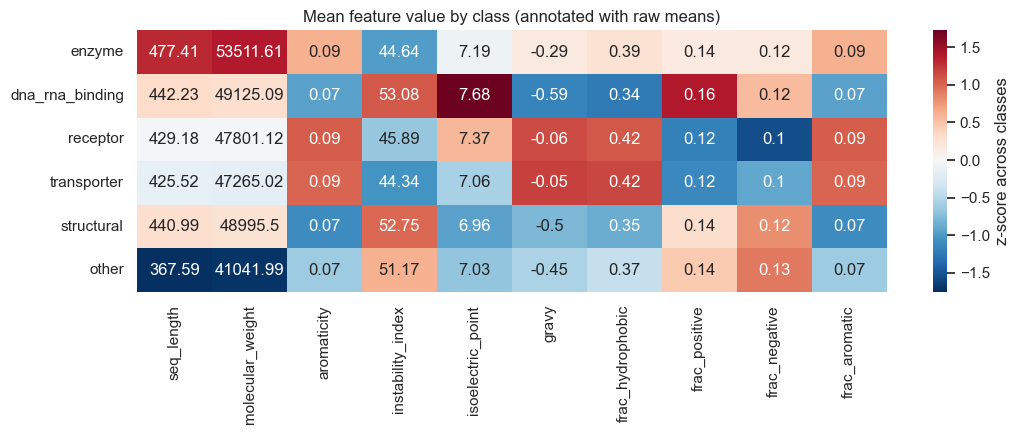

In [8]:
# z-score each column so groups are comparable on one heatmap.
z = (by_class - by_class.mean()) / by_class.std()

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(z, annot=by_class.round(2), fmt="", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score across classes"}, ax=ax)
ax.set_title("Mean feature value by class (annotated with raw means)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_means_by_class.png", dpi=150)
plt.show()

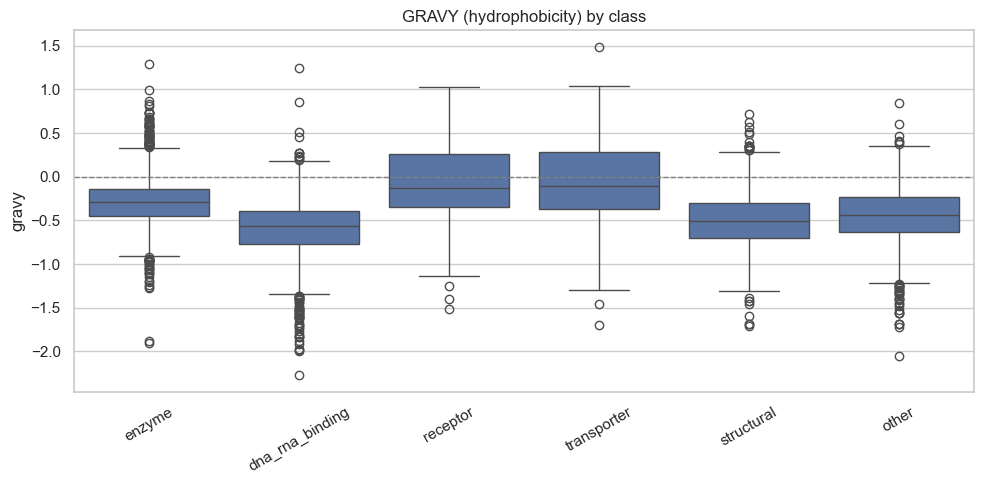

In [9]:
# GRAVY (hydrophobicity) by class — the feature most likely to flag transporters.
fig, ax = plt.subplots()
sns.boxplot(data=feats.reset_index(), x="function_class", y="gravy",
            order=CLASS_ORDER, ax=ax)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_title("GRAVY (hydrophobicity) by class")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "gravy_by_class.png", dpi=150)
plt.show()

### Interpretation

_Fill in after running._ Look for:

- **GRAVY / frac_hydrophobic:** transporters should skew positive (more
  hydrophobic, consistent with membrane-spanning regions). If they do, that's the
  single most useful handcrafted feature.
- **isoelectric_point / charge fractions:** DNA/RNA-binding proteins often skew
  basic (positive `pI`) because they bind negatively-charged nucleic acids.
- **molecular_weight / seq_length:** weak separators on their own (EDA confirmed),
  but may help in combination.

These are the signals the Day 5 baseline will lean on, and the features Day 7
interpretability will explain.

## 4. Save

Output goes to `data/processed/sequence_features.csv`, indexed by `accession`,
with `function_class` carried through so Day 5 can load features + labels in one
read.

In [10]:
out_path = PROCESSED_DIR / "sequence_features.csv"
feats.to_csv(out_path)
print(f"Saved {feats.shape[0]} rows x {feats.shape[1]} cols -> {out_path}")
feats.head()

Saved 8520 rows x 33 cols -> C:\Users\sridi\Documents\Learning\protein-function-active-learning\data\processed\sequence_features.csv


,function_class,seq_length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,frac_hydrophobic,frac_polar_uncharged,frac_positive,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
accession,,,,,,,,,,,,,,,,,,,,,
A0A1B0GTW7,enzyme,788,85395.9714,0.065990,41.752284,8.038192,-0.141624,0.380711,0.393401,0.121827,...,0.016497,0.017766,0.077411,0.050761,0.050761,0.096447,0.060914,0.053299,0.016497,0.025381
A0JP26,other,581,65709.6952,0.041308,48.240448,6.239750,-0.775387,0.333907,0.314974,0.177281,...,0.030981,0.060241,0.027539,0.051635,0.049914,0.080895,0.037866,0.046472,0.008606,0.017212
A0PK11,transporter,232,25445.8398,0.112069,31.439655,6.508372,0.757759,0.556034,0.254310,0.090517,...,0.017241,0.025862,0.030172,0.038793,0.025862,0.056034,0.030172,0.107759,0.021552,0.025862
A1A4S6,structural,786,89373.5585,0.083969,50.047226,6.751472,-0.585623,0.346056,0.334606,0.160305,...,0.022901,0.044529,0.063613,0.043257,0.055980,0.080153,0.053435,0.052163,0.008906,0.021628
A1A519,dna_rna_binding,330,37157.5659,0.045455,74.251212,4.997989,-1.018485,0.260606,0.400000,0.145455,...,0.033333,0.027273,0.054545,0.063636,0.063636,0.121212,0.066667,0.066667,0.012121,0.015152
